<a href="https://colab.research.google.com/github/muhammadtegarkurniawan/Tugas/blob/main/Pertemuan6_23423045.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Warna_Kucing.width-800.format-webp.webp to Warna_Kucing.width-800.format-webp (1).webp
Hasil ()


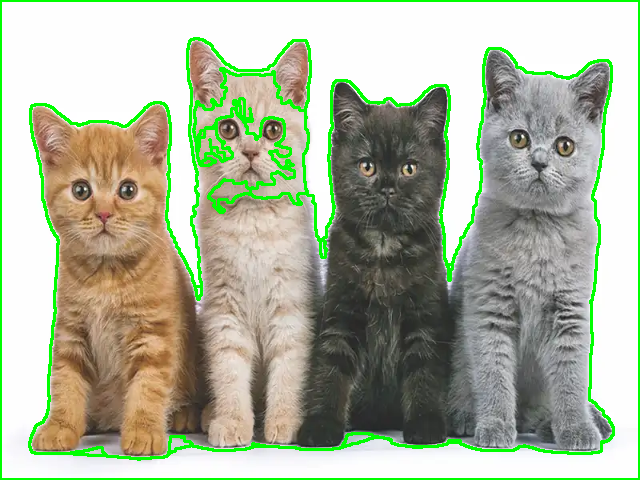

In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files

def segment_fix_telinga(image_path, k=4):
    img = cv2.imread(image_path)
    if img is None:
        print("Gambar tidak ditemukan!")
        return

    img = cv2.resize(img, (640, 480))
    output = img.copy()

    # --- EDGE ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    edges = cv2.Canny(blur, 30, 120)

    # 🔥 Pertebal edge (biar telinga ikut)
    edges = cv2.dilate(edges, np.ones((3,3), np.uint8), iterations=2)

    # --- KMEANS ---
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pixel_vals = img_rgb.reshape((-1, 3)).astype(np.float32)

    _, labels, _ = cv2.kmeans(
        pixel_vals, k, None,
        (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2),
        10, cv2.KMEANS_RANDOM_CENTERS
    )

    segmented = labels.reshape((img.shape[0], img.shape[1]))

    kernel = np.ones((5,5), np.uint8)

    for i in range(k):
        mask = np.uint8(segmented == i) * 255

        # 🔥 Tutup lubang besar
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

        # 🔥 Gabung dengan edge (yang sudah diperlebar)
        combined = cv2.bitwise_or(mask, edges)

        # 🔥 Fill hole biar solid (INI PENTING BANGET)
        h, w = combined.shape
        floodfill = combined.copy()
        mask_ff = np.zeros((h+2, w+2), np.uint8)
        cv2.floodFill(floodfill, mask_ff, (0,0), 255)
        floodfill_inv = cv2.bitwise_not(floodfill)
        combined = combined | floodfill_inv

        # Kontur luar
        contours, _ = cv2.findContours(combined, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

        for cnt in contours:
            if cv2.contourArea(cnt) > 2000:
                cv2.drawContours(output, [cnt], -1, (0,255,0), 2)

    print("Hasil ()")
    cv2_imshow(output)


# Upload
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Run
segment_fix_telinga(image_path, k=4)